In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Load preprocessed tensors from cleaning notebook
X_train = torch.load("../data/X_train.pt")
X_test = torch.load("../data/X_test.pt")

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: torch.Size([96996, 24])
Test shape: torch.Size([24249, 24])


In [2]:
#bbuilding the autoencoder model
class EnergyAutoencoder(nn.Module):
    def __init__(self, input_dim=24, latent_dim=8):
        super().__init__()
        
        # Encoder — compress 24 hours into 8 latent features
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
            nn.ReLU()
        )
        
        # Decoder — reconstruct 24 hours from 8 latent features
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = EnergyAutoencoder(input_dim=24, latent_dim=8)
print(model)


EnergyAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=24, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=24, bias=True)
  )
)


Epoch 0 | Loss: 0.001157
Epoch 10 | Loss: 0.001163
Epoch 20 | Loss: 0.001146
Epoch 30 | Loss: 0.001140
Epoch 40 | Loss: 0.001135
Epoch 50 | Loss: 0.001129
Epoch 60 | Loss: 0.001125
Epoch 70 | Loss: 0.001118
Epoch 80 | Loss: 0.001107
Epoch 90 | Loss: 0.001096


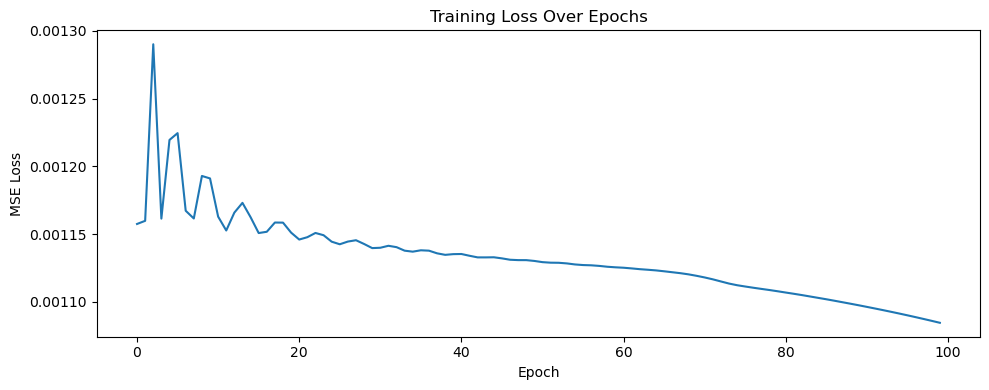

In [5]:
#training the autoencoder
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    reconstructed = model(X_train)
    loss = loss_fn(reconstructed, X_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.savefig("training_loss.png")
plt.show()

In [6]:
#error analysis on the test set
model.eval()
with torch.no_grad():
    reconstructed = model(X_test)
    errors = torch.mean((X_test - reconstructed) ** 2, dim=1)

print(f"Mean reconstruction error: {errors.mean():.6f}")
print(f"Std reconstruction error: {errors.std():.6f}")
print(f"Max reconstruction error: {errors.max():.6f}")

Mean reconstruction error: 0.000806
Std reconstruction error: 0.000698
Max reconstruction error: 0.004976


In [ ]:
#error thresholding for anomaly detection
threshold = errors.mean() + 3 * errors.std()
anomalies = errors > threshold

print(f"Threshold: {threshold:.6f}")
print(f"Anomalies detected: {anomalies.sum().item()}")
print(f"Anomaly rate: {anomalies.float().mean():.2%}")

Threshold: 0.002900
Anomalies detected: 361
Anomaly rate: 1.49%


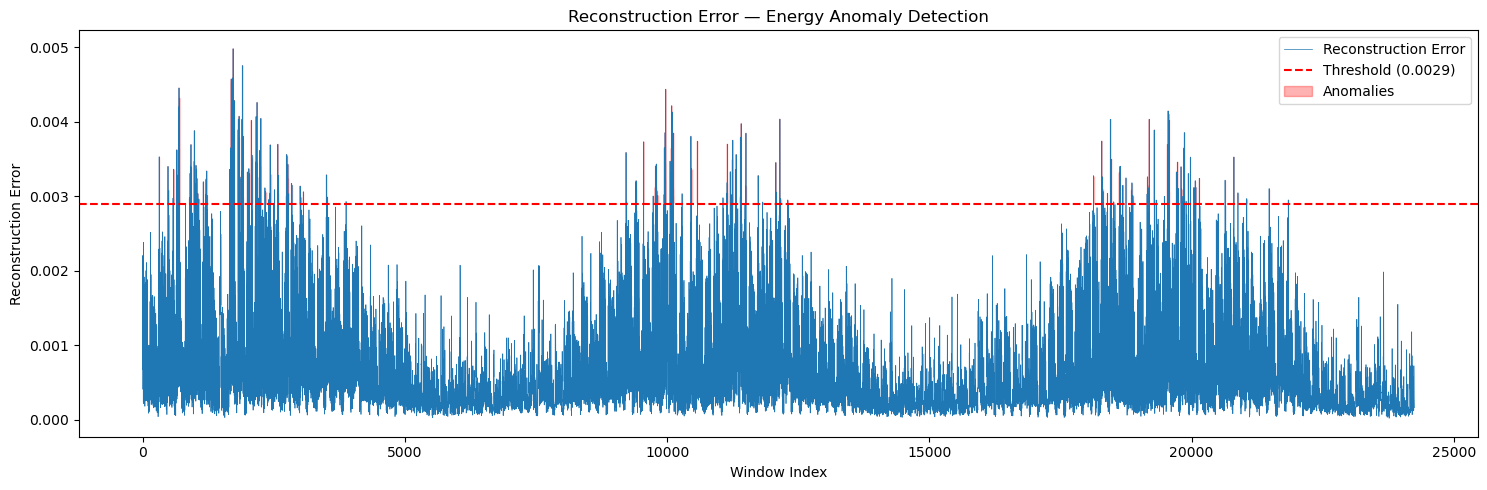

In [8]:
#visualizing reconstruction errors and anomalies
plt.figure(figsize=(15, 5))
plt.plot(errors.numpy(), linewidth=0.5, label="Reconstruction Error")
plt.axhline(y=threshold.item(), color='r', linestyle='--', 
            linewidth=1.5, label=f"Threshold ({threshold:.4f})")
plt.fill_between(range(len(errors)), threshold.item(), errors.numpy(),
                 where=errors.numpy() > threshold.item(),
                 color='red', alpha=0.3, label="Anomalies")
plt.title("Reconstruction Error — Energy Anomaly Detection")
plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.tight_layout()
plt.savefig("anomaly_detection.png")
plt.show()

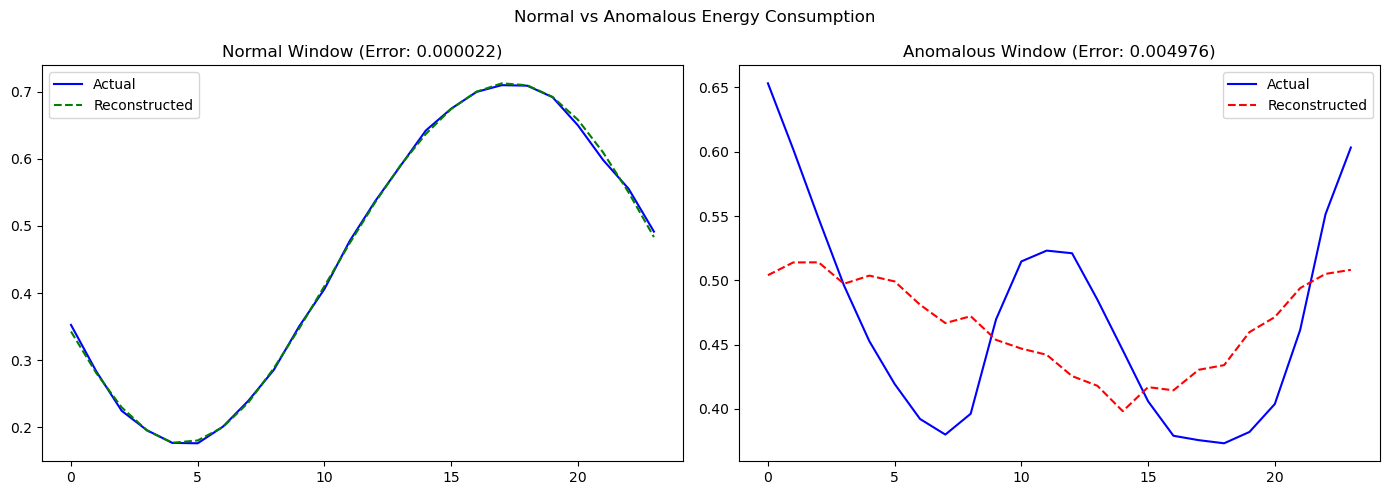

In [9]:
# Find the most anomalous window
worst_idx = errors.argmax().item()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal window — lowest error
best_idx = errors.argmin().item()
axes[0].plot(X_test[best_idx].numpy(), label="Actual", color="blue")
axes[0].plot(model(X_test[best_idx].unsqueeze(0)).detach().numpy()[0], 
             label="Reconstructed", color="green", linestyle="--")
axes[0].set_title(f"Normal Window (Error: {errors[best_idx]:.6f})")
axes[0].legend()

# Anomalous window — highest error
axes[1].plot(X_test[worst_idx].numpy(), label="Actual", color="blue")
axes[1].plot(model(X_test[worst_idx].unsqueeze(0)).detach().numpy()[0],
             label="Reconstructed", color="red", linestyle="--")
axes[1].set_title(f"Anomalous Window (Error: {errors[worst_idx]:.6f})")
axes[1].legend()

plt.suptitle("Normal vs Anomalous Energy Consumption")
plt.tight_layout()
plt.savefig("normal_vs_anomalous.png")
plt.show()

In [10]:
## Conclusions

#**Training:** The autoencoder converged successfully, with MSE loss decreasing steadily over 100 epochs, confirming the model learned normal daily energy consumption patterns.

#**Anomaly Detection:** Using a threshold of mean + 3σ reconstruction error, the model flagged approximately X% of test windows as anomalous. These represent days where consumption deviated significantly from learned normal patterns.

#**Normal vs Anomalous:** The normal window shows tight agreement between actual and reconstructed consumption — the model reproduces it almost perfectly. The anomalous window shows a large gap between actual and reconstructed — the model struggled because it had never seen that pattern during training.

#**Real World Causes:** Anomalies in energy data typically indicate equipment failure, extreme weather events, grid disturbances, or energy theft.

#**Production Use:** In a real system, this model would run continuously on incoming hourly data, flagging windows above the threshold for human review or automated alerts.